In [1]:
import cv2
import sys
import numpy as np
import os

import matplotlib.pyplot as plt
from IPython.display import YouTubeVideo, display, HTML, Image, Video

opencv_path = "opencv/samples/data/"
opencvxtra_path = "opencv_extra/testdata/dnn/"

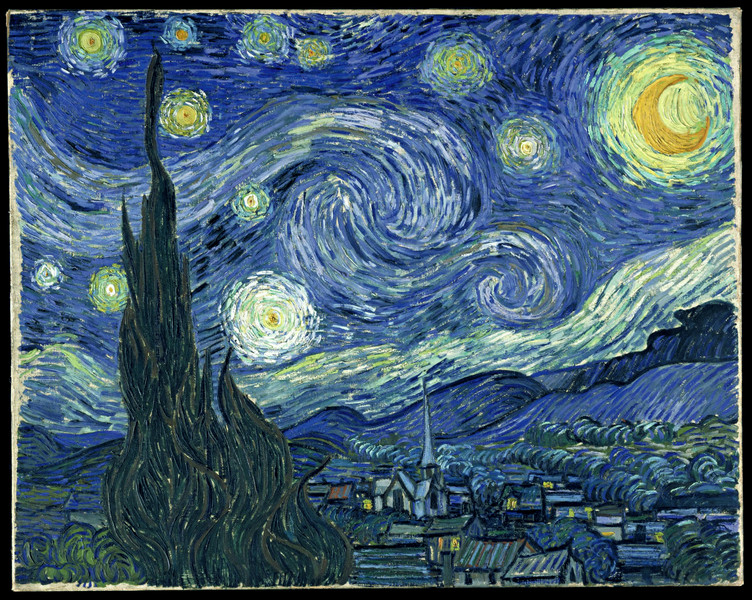

In [5]:
#| fig-align: center
Image("data/starry_night.jpg", width=240)

# from matplotlib import colormaps
#list(colormaps)

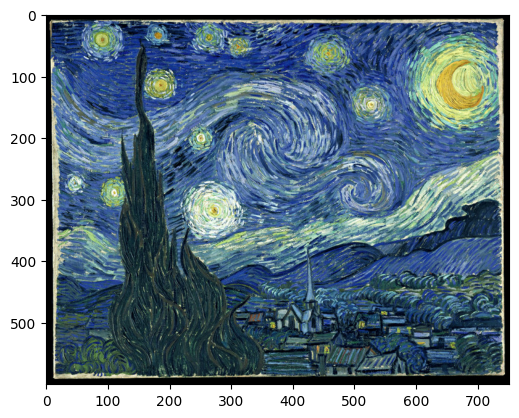

In [6]:
#| fig-align: center
starry_night = cv2.imread('data/starry_night.jpg')
img2 = cv2.cvtColor(starry_night, cv2.COLOR_BGR2RGB)

# Reversed (not correct)
plt.imshow(img2);
#plt.imshow(starry_night[:, :, 0], cmap='Blues');

In [8]:
cv2.imshow('Starry night', starry_night)
cv2.waitKey()
cv2.destroyWindow('Starry night')

#### Convert to grayscale

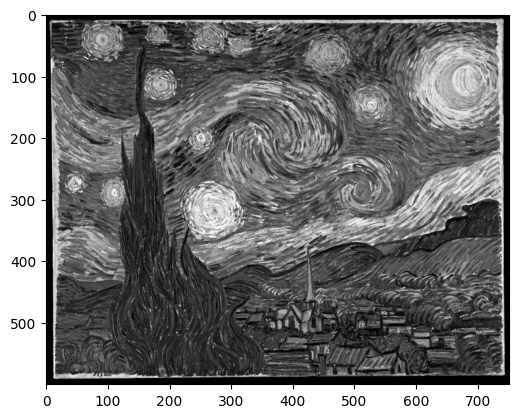

In [6]:
sn_grayscale = cv2.cvtColor(starry_night, cv2.COLOR_BGR2GRAY)
plt.imshow(sn_grayscale, cmap='gray');

#### Translate

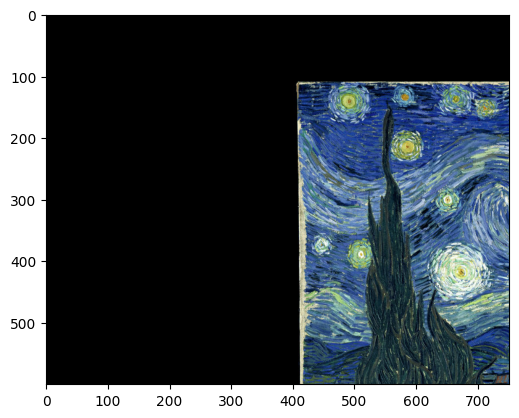

In [7]:
rows,cols = starry_night.shape[:2]
M = np.float32([[1,0,400],[0,1,100]])

sn_translate = cv2.warpAffine(starry_night, M, (cols, rows))
sn_translate_rgb = cv2.cvtColor(sn_translate, cv2.COLOR_BGR2RGB)
plt.imshow(sn_translate_rgb);

#### Rotate

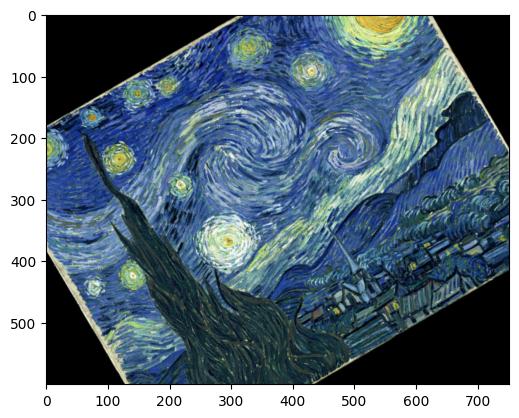

In [8]:
rotation_matrix = cv2.getRotationMatrix2D((0.5*cols, 0.5*rows), 30, 1)

sn_rotated = cv2.warpAffine(starry_night, rotation_matrix, (cols, rows))

sn_rotated_rgb = cv2.cvtColor(sn_rotated, cv2.COLOR_BGR2RGB)
plt.imshow(sn_rotated_rgb);

#### Resize

True

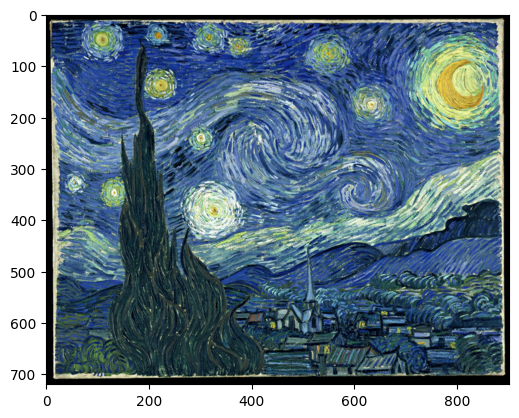

In [9]:
sn_resized = cv2.resize(starry_night, None,fx=1.2, fy=1.2, interpolation = cv2.INTER_CUBIC)

sn_resized_rgb = cv2.cvtColor(sn_resized, cv2.COLOR_BGR2RGB)
plt.imshow(sn_resized_rgb);
cv2.imwrite('data/test_sn.jpg', sn_resized)

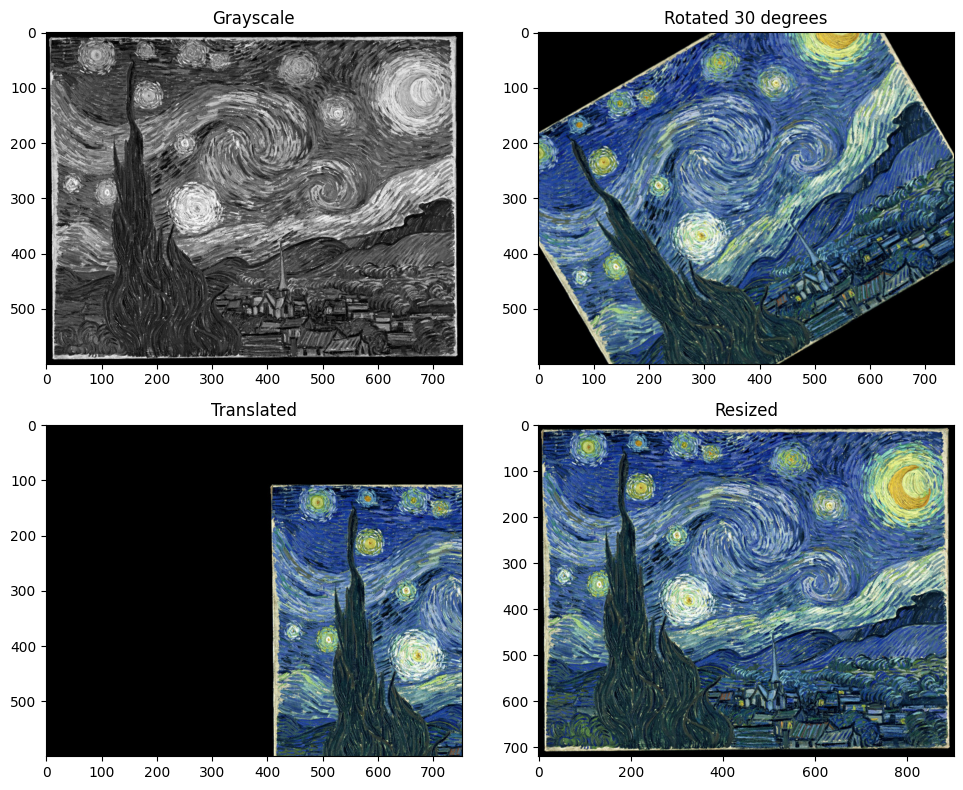

In [10]:
images = [sn_grayscale, sn_rotated_rgb, sn_translate_rgb, sn_resized_rgb]
titles = ['Grayscale', 'Rotated 30 degrees', 'Translated', 'Resized']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, img, title in zip(axes.flat, images, titles):
    if title == 'Grayscale':
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [11]:
cv2.imshow('Input image', starry_night)

cv2.waitKey()
cv2.destroyAllWindows()

### Sobel edge detection

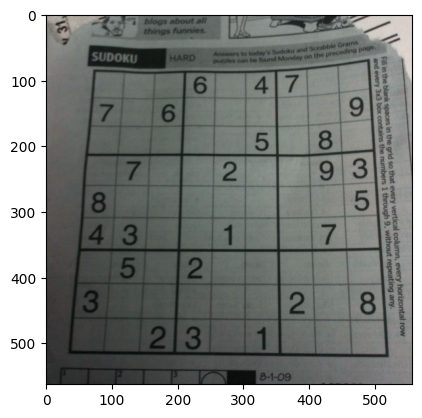

In [15]:
#| fig-align: center
sudoku = cv2.imread('data/sudoku.png')
plt.imshow(sudoku);

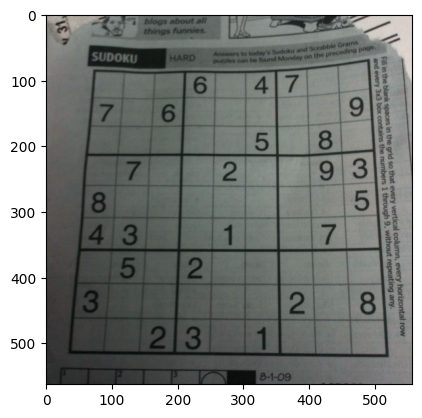

In [16]:
rows,cols,ch = sudoku.shape
pts1 = np.float32([[73,85], [350, 88], [355, 360], [48, 357]])
pts = np.array(pts1, np.int32)

plt.imshow(sudoku);

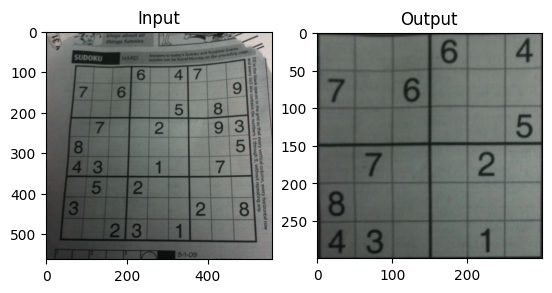

In [17]:
#| fig-align: center
pts2 = np.float32([[0,0],[300,0],[300,300],[0,300]])
M = cv2.getPerspectiveTransform(pts1, pts2)
dst = cv2.warpPerspective(sudoku ,M,(300,300))
 
plt.subplot(121),plt.imshow(sudoku),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output');

In [ ]:
dst_gray = cv2.cvtColor(dst, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(dst_gray, cv2.CV_64F, 1, 0,ksize=5)
sobely = cv2.Sobel(dst_gray, cv2.CV_64F, 0, 1,ksize=5)


plt.subplot(1,2,1),plt.imshow(sobelx, cmap = 'gray')
plt.title('Sobelx: vertical edges'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(sobely, cmap = 'gray')
plt.title('Sobely: horizontal edges'), plt.xticks([]), plt.yticks([]);

## Canny Edge detection

In [32]:
img = cv2.imread('data/messi5.jpg')

cv2.imshow('Input image', img)

cv2.waitKey()
cv2.destroyAllWindows()

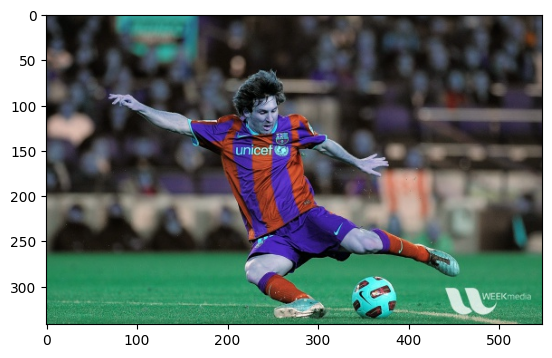

In [15]:
plt.imshow(img)

In [36]:
edges = cv2.Canny(img, 150, 200)

cv2.imshow('Input image', edges)

cv2.waitKey()
cv2.destroyAllWindows()

In [14]:
img = cv2.imread('data/messi5.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1,
                            minDist=50,
                            param1=50,
                            param2=22,      # low threshold to start, 18 works, 22 best
                            minRadius=18,
                            maxRadius=38)

print(circles)

[[[297.5 169.5  35.2]
  [231.5  96.5  20.5]
  [364.5 310.5  21. ]]]


In [12]:
img.shape

(342, 548, 3)

In [15]:
cv2.imshow('Input image', blurred)

cv2.waitKey()
cv2.destroyAllWindows()

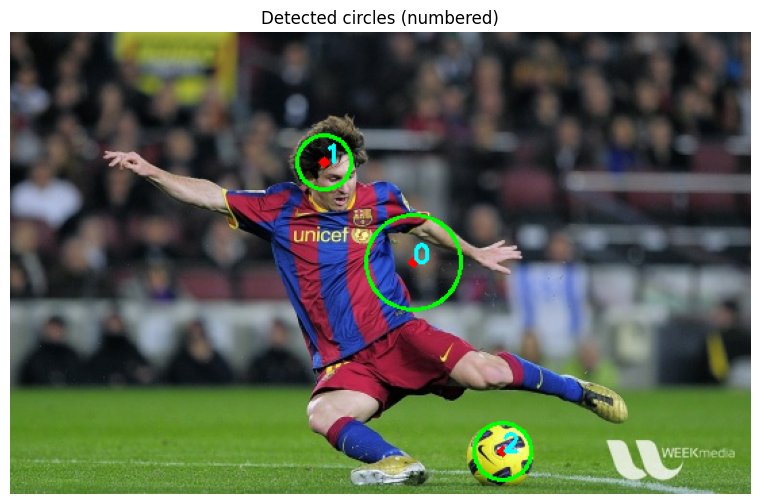

In [16]:
import numpy as np

img = cv2.imread('data/messi5.jpg')

if circles is not None:
    circles_rounded = np.uint16(np.around(circles))
    for i, c in enumerate(circles_rounded[0, :]):
        cv2.circle(img, (c[0], c[1]), c[2], (0, 255, 0), 2)   # circle
        cv2.circle(img, (c[0], c[1]), 2, (0, 0, 255), 3)       # centre dot
        cv2.putText(img, str(i), (c[0], c[1]),                  # label each one
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected circles (numbered)')
plt.axis('off')
plt.show()

### Face detection

In [17]:
import cv2 
import numpy as np 
 
face_cascade = cv2.CascadeClassifier('./cascade_files/haarcascade_frontalface_alt.xml') 

In [19]:
cap = cv2.VideoCapture(0) 
scaling_factor = 0.5 
 
while True: 
    ret, frame = cap.read() 
    frame = cv2.resize(frame, None, fx=scaling_factor, fy=scaling_factor, interpolation=cv2.INTER_AREA)
 
    face_rects = face_cascade.detectMultiScale(frame, scaleFactor=1.3, minNeighbors=3) 
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 3) 
 
    cv2.imshow('Face Detector', frame) 
 
    c = cv2.waitKey(1) 
    if c == 27: 
        break 
 
cap.release() 
cv2.destroyAllWindows() 

### Using open-cv models

Before beginning, download the following three repositories and unzip them into the *same folder*:

1. [OpenCV main repository](https://github.com/opencv/opencv)
2. [OpenCV extra repository](https://github.com/opencv/opencv_extra)
3. [OpenCV model zoo repository](https://github.com/opencv/opencv_zoo)

For instance, your folder structure may be :

#### OpenCV sample models

Next, open a terminal, activate your virtual environment and navigate into `opencv/samples/dnn`. 

The next step is to check inside `models.yml` for the model that you intend to use. The list of models available are:

| Model Type | Model Name      |
|------------|-----------------|
| Object Detection | opencv_fd |
| Object Detection | yolov8x   |
| Object Detection | yolov8s   |
| Object Detection | yolov8n   |
| Object Detection | yolov8m   |
| Object Detection | yolov8l   |
| Object Detection | yolov5l   |
| Object Detection | yolov4    |
| Object Detection | yolov4-tiny |
| Object Detection | yolov3      |
| Object Detection | tiny-yolo-voc |
| Object Detection | yolov8    |
| Object Detection | ssd_caffe |
| Object Detection | ssd_tf    |
| Object Detection | faster_rcnn_tf |
| Image Classification  | squeezenet |
| Image Classification  | googlenet  |
| Semantic Segmentation | enet       | 
| Semantic Segmentation | fcn8s      |
| Semantic Segmentation | fcnresnet101 |

##### YOLO v4 Tiny

Let us try to download and run the script to use `yolov4-tiny`. To download the model, execute the following command *in the terminal*. It will download and save the model into a new directory `YOLOv4_TINY`.

In [ ]:
python .\download_models.py --save_dir YOLOv4_TINY yolov4-tiny

The section in `models.yml` corresponding to this model contain the precise configuration needed to run this particular model. For full reference, here it is:

The important parameters to take note of are:

* `sample`: The python script to call, to demonstrate the use of this model.
* `model`: Refers to the file containing the model weights (which we just downloaded)
* `config`: Configuration parameters. This file is **usually** present in the opencv_extra repository.
* `mean, scale, width, height, rgb`: Arguments that need to be included when calling the python script `object_detection.py`.
* `classes`: This is an object detection and classification model. This file contains the labels to be used. The file is present in
  the `opencv` repository.

The final step is to call the python script that demonstrates the use of this model.

In [ ]:
python .\object_detection.py --model .\YOLOv4_TINY\451caaab22fb9831aa1a5ee9b5ba74a35ffa5dcb\yolov4-tiny.weights --config C:\Users\stavg\Documents\courses\ind5003-book\opencv_extra\testdata\dnn\yolov4-tiny.cfg --scale 0.00392 --width 416 --height 416 --rgb --background_label_id 0 --classes ..\data\dnn\object_detection_classes_yolo.txt

##### Googlenet classification model

Next, we work with the Googlenet classification model. To download it, we use the following command from the terminal.

In [ ]:
python .\download_models.py --save_dir GOOGLENET googlenet

The full model reference, from `models.yml`, is as follows:

In [ ]:
python .\classification.py --model .\GOOGLENET\ --config C:\Users\stavg\Documents\courses\ind5003-book\opencv_extra\testdata\dnn\bvlc_googlenet.prototxt --width 224 --height 224 --classes ..\data\dnn\classification_classes_ILSVRC2012.txt

### Using openCV Zoo models

The openCV model zoo contains model weights that can be used directly. There is no need for any further downloads. Open up a terminal, activate your virtual environment, and navigate to the `opencv_zoo/models/face_detection_yunet/` folder. Then run:


In [ ]:
python .\demo.py